# K-Moda MMM — Fase 8: Budget Simulator

**Objetivo:** Dado el ROAS por canal, optimizar la asignación de presupuesto para maximizar ventas esperadas bajo distintos escenarios.

**Metodología:** Programación lineal con restricciones de floor/ceiling por canal (scipy.optimize.linprog).

**Restricciones:**
- Presupuesto total fijo por escenario
- Cada canal recibe mínimo 30% y máximo 250% de su inversión histórica media
- Solo canales con ROAS > 0 son optimizables

**Input:** `data/df_modelo_final.parquet` · `data/df_inversion_clean.parquet`  
**Output:** `data/df_budget_optimizado.parquet`

## 1. Configuración e Imports

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy.optimize import linprog

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
}
CANAL_COLORS = [
    KM['paid_search'], KM['social_paid'], KM['video'], KM['display'],
    KM['email_crm'],   KM['radio'],       KM['exterior'], KM['prensa'],
]
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 2. Carga de datos

In [12]:
df_roas = pd.read_parquet(DATA_OUT / 'df_modelo_final.parquet')
df_inv  = pd.read_parquet(DATA_OUT / 'df_inversion_clean.parquet')

# Inversión histórica media semanal (train 2020-2023)
TRAIN_END = pd.Timestamp('2023-12-31')
df_inv_train = df_inv[df_inv['semana_inicio'] <= TRAIN_END]
CANALES_INV = [c for c in df_inv.columns
               if c not in ['semana_inicio','anio','anio_iso','semana_iso']]

inv_media_semanal = df_inv_train[CANALES_INV].mean()  # EUR/semana
inv_total_semanal = inv_media_semanal.sum()
inv_total_anual   = inv_total_semanal * 52

print('INVERSION HISTORICA MEDIA (train 2020-2023):')
print(f'  Total semanal:  {inv_total_semanal:>10,.0f} EUR')
print(f'  Total anual:    {inv_total_anual:>10,.0f} EUR')
print()
print(f'{"Canal":20s}  {"Media semanal":>15s}  {"% del total":>12s}')
print('-' * 52)
for canal in CANALES_INV:
    v = inv_media_semanal[canal]
    print(f'{canal:20s}  {v:>15,.0f} EUR  {v/inv_total_semanal*100:>11.1f}%')

INVERSION HISTORICA MEDIA (train 2020-2023):
  Total semanal:     212,440 EUR
  Total anual:    11,046,890 EUR

Canal                   Media semanal   % del total
----------------------------------------------------
Display                        17,124 EUR          8.1%
Email CRM                      10,418 EUR          4.9%
Exterior                       25,679 EUR         12.1%
Paid Search                    47,302 EUR         22.3%
Prensa                         19,373 EUR          9.1%
Radio Local                    23,515 EUR         11.1%
Social Paid                    37,178 EUR         17.5%
Video Online                   31,850 EUR         15.0%


## 3. Matching ROAS ↔ Canales de inversión

In [13]:
# Usamos ROAS mediana (más robusta que la media cuando hay clipping a 0)
# Canales con mediana=0 tienen distribución posterior concentrada en 0 → no optimizables
roas_dict = {r['Canal'].upper(): r['ROAS median'] for _, r in df_roas.iterrows()}
inv_dict  = {c.upper(): inv_media_semanal[c] for c in CANALES_INV}

canales, roas_vals, inv_vals = [], [], []
for c_orig in CANALES_INV:
    key = c_orig.upper()
    roas_v = roas_dict.get(key, 0.0)
    canales.append(c_orig)
    roas_vals.append(roas_v)
    inv_vals.append(inv_media_semanal[c_orig])

df_base = pd.DataFrame({
    'Canal':          canales,
    'Inv_actual_sem': inv_vals,
    'ROAS':           roas_vals,
})
df_base['Ventas_attr_sem'] = df_base['Inv_actual_sem'] * df_base['ROAS']
df_base['Optimizable']     = df_base['ROAS'] > 0

print('TABLA BASE (inversion actual + ROAS mediana):')
print(df_base.to_string(index=False))
print()
print(f'Canales optimizables (ROAS mediana > 0): {df_base["Optimizable"].sum()} / {len(df_base)}')
print(f'Canales fijos (ROAS mediana = 0):        {(~df_base["Optimizable"]).sum()}')
print()
print(f'Ventas atribuidas totales/semana: {df_base["Ventas_attr_sem"].sum():,.0f} EUR')


TABLA BASE (inversion actual + ROAS mediana):
       Canal  Inv_actual_sem  ROAS  Ventas_attr_sem  Optimizable
     Display    17123.931435  0.00         0.000000        False
   Email CRM    10418.302440  0.00         0.000000        False
    Exterior    25679.225263 18.72    480715.096926         True
 Paid Search    47302.220813  2.74    129608.085029         True
      Prensa    19373.416603  0.00         0.000000        False
 Radio Local    23514.560478  1.80     42326.208861         True
 Social Paid    37178.383206  3.58    133098.611877         True
Video Online    31850.150909  0.00         0.000000        False

Canales optimizables (ROAS mediana > 0): 4 / 8
Canales fijos (ROAS mediana = 0):        4

Ventas atribuidas totales/semana: 785,748 EUR


## 4. Optimización de presupuesto

Maximizar `Σ ROAS_i · x_i` sujeto a:
- `Σ x_i = Budget`  
- `0.30 · inv_actual_i ≤ x_i ≤ 2.50 · inv_actual_i`  (floor/ceiling)
- Para canales con ROAS=0: `x_i = inv_actual_i` (sin cambio)

In [14]:
def optimizar_presupuesto(df, budget_total, floor=0.30, ceiling=2.50):
    """
    Programacion lineal: maximiza ROAS * x sujeto a budget y bounds por canal.
    Canales con ROAS=0 mantienen inversion actual.
    """
    opt_mask  = df['Optimizable'].values
    fixed_inv = df.loc[~opt_mask, 'Inv_actual_sem'].sum()
    budget_opt = budget_total - fixed_inv  # presupuesto disponible para canales optimizables

    df_opt = df[opt_mask].reset_index(drop=True)
    n = len(df_opt)

    # linprog minimiza, por eso negamos ROAS
    c_obj = -df_opt['ROAS'].values

    # Restriccion de igualdad: suma = budget_opt
    A_eq = np.ones((1, n))
    b_eq = np.array([budget_opt])

    # Bounds
    bounds = [(floor * inv, ceiling * inv)
              for inv in df_opt['Inv_actual_sem'].values]

    res = linprog(c_obj, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

    if not res.success:
        return None, res.message

    # Reconstruir resultado completo
    result = df.copy()
    result['Inv_optima'] = result['Inv_actual_sem'].copy()
    result.loc[opt_mask, 'Inv_optima'] = res.x
    result['Ventas_optimas'] = result['Inv_optima'] * result['ROAS']
    result['Delta_inv']  = result['Inv_optima'] - result['Inv_actual_sem']
    result['Delta_pct']  = result['Delta_inv'] / result['Inv_actual_sem'] * 100

    return result, 'OK'

print('Funcion de optimizacion lista.')
print(f'Canales optimizables: {df_base["Optimizable"].sum()} / {len(df_base)}')
print(f'Canales fijos (ROAS=0): {(~df_base["Optimizable"]).sum()}')

Funcion de optimizacion lista.
Canales optimizables: 4 / 8
Canales fijos (ROAS=0): 4


## 5. Escenarios de presupuesto

In [15]:
ESCENARIOS = {
    'Actual (-10%)':  inv_total_semanal * 0.90,
    'Actual (base)':  inv_total_semanal * 1.00,
    'Actual (+10%)':  inv_total_semanal * 1.10,
    'Actual (+20%)':  inv_total_semanal * 1.20,
    'Actual (+30%)':  inv_total_semanal * 1.30,
}

ventas_actual = df_base['Ventas_attr_sem'].sum()

print(f'Ventas atribuidas actuales: {ventas_actual:>10,.0f} EUR/semana')
print()
print(f'{"Escenario":20s}  {"Budget/sem":>12s}  {"Ventas opt":>12s}  {"Uplift":>10s}')
print('-' * 62)

resultados_esc = {}
for nombre, budget in ESCENARIOS.items():
    res, msg = optimizar_presupuesto(df_base, budget)
    if res is not None:
        ventas_opt = res['Ventas_optimas'].sum()
        uplift = (ventas_opt - ventas_actual) / ventas_actual * 100
        resultados_esc[nombre] = {'budget': budget, 'ventas': ventas_opt,
                                  'uplift': uplift, 'df': res}
        print(f'{nombre:20s}  {budget:>12,.0f}  {ventas_opt:>12,.0f}  {uplift:>+9.1f}%')
    else:
        print(f'{nombre:20s}  ERROR: {msg}')

Ventas atribuidas actuales:    785,748 EUR/semana

Escenario               Budget/sem    Ventas opt      Uplift
--------------------------------------------------------------
Actual (-10%)              191,196     1,349,982      +71.8%
Actual (base)              212,440     1,426,036      +81.5%
Actual (+10%)              233,684     1,502,090      +91.2%
Actual (+20%)              254,928     1,578,143     +100.8%
Actual (+30%)              276,172     1,638,222     +108.5%


In [16]:
df_opt_base = resultados_esc['Actual (base)']['df']

print('REDISTRIBUCION OPTIMA — presupuesto actual:')
print(f'{"Canal":20s}  {"Actual":>12s}  {"Optimo":>12s}  {"Delta":>10s}  {"ROAS":>6s}  {"Estado":>8s}')
print('-' * 78)
for _, r in df_opt_base.sort_values('ROAS', ascending=False).iterrows():
    estado = 'FIJO' if r['ROAS'] == 0 else 'optim.'
    print(f'{r["Canal"]:20s}  {r["Inv_actual_sem"]:>12,.0f}  '
          f'{r["Inv_optima"]:>12,.0f}  '
          f'{r["Delta_pct"]:>+9.1f}%  '
          f'{r["ROAS"]:>6.2f}x  '
          f'{estado:>8s}')
print(f'\nTotal actual:  {df_opt_base["Inv_actual_sem"].sum():>12,.0f}')
print(f'Total optimo:  {df_opt_base["Inv_optima"].sum():>12,.0f}')


REDISTRIBUCION OPTIMA — presupuesto actual:
Canal                       Actual        Optimo       Delta    ROAS    Estado
------------------------------------------------------------------------------
Exterior                    25,679        64,198     +150.0%   18.72x    optim.
Social Paid                 37,178        48,231      +29.7%    3.58x    optim.
Paid Search                 47,302        14,191      -70.0%    2.74x    optim.
Radio Local                 23,515         7,054      -70.0%    1.80x    optim.
Display                     17,124        17,124       +0.0%    0.00x      FIJO
Email CRM                   10,418        10,418       +0.0%    0.00x      FIJO
Prensa                      19,373        19,373       +0.0%    0.00x      FIJO
Video Online                31,850        31,850       +0.0%    0.00x      FIJO

Total actual:       212,440
Total optimo:       212,440


## 6. Visualización — actual vs óptimo

  Guardado: img\08a_actual_vs_optimo.png


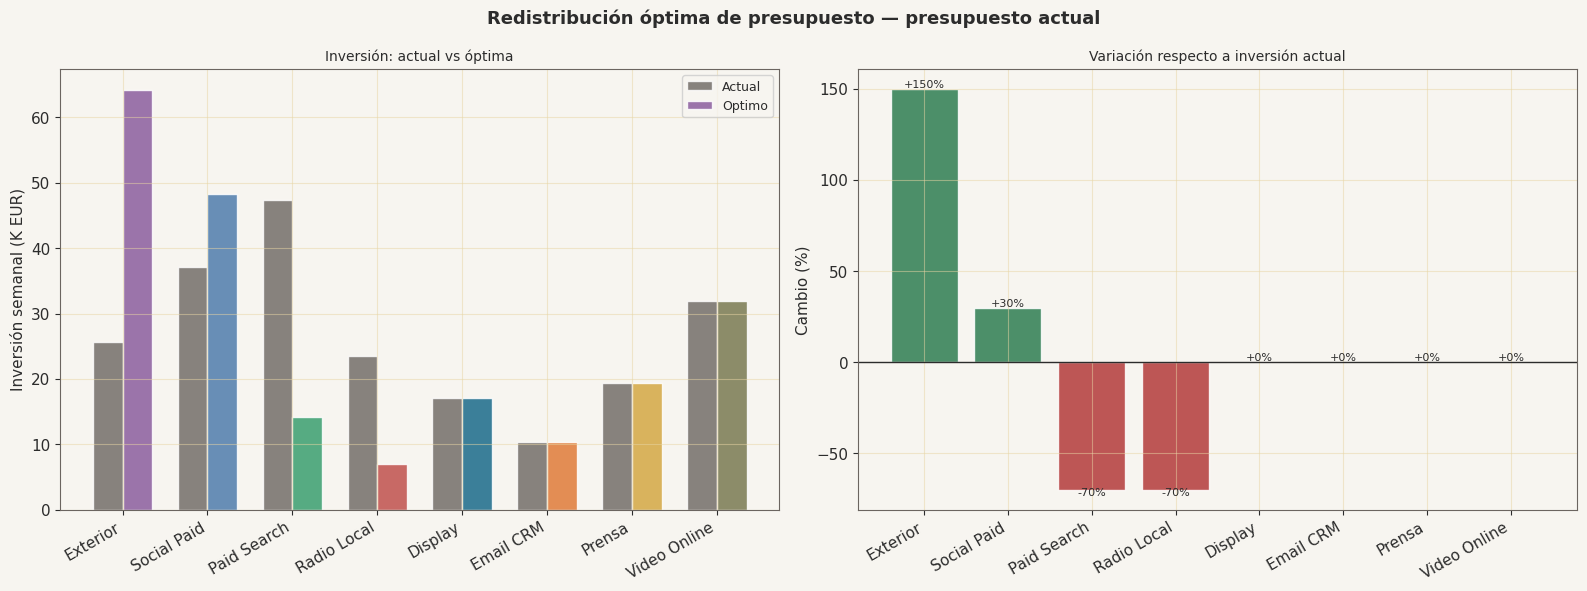

In [17]:
df_plot = df_opt_base.sort_values('ROAS', ascending=False).reset_index(drop=True)
color_map = dict(zip(
    [c.upper() for c in CANALES_INV],
    CANAL_COLORS[:len(CANALES_INV)]
))
bar_colors = [color_map.get(c.upper(), KM['warm_gray']) for c in df_plot['Canal']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Redistribución óptima de presupuesto — presupuesto actual',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Barras: actual vs optimo
ax = axes[0]
x = np.arange(len(df_plot))
w = 0.35
ax.bar(x - w/2, df_plot['Inv_actual_sem']/1e3, w, label='Actual',
       color=KM['warm_gray'], alpha=0.8, edgecolor='white')
ax.bar(x + w/2, df_plot['Inv_optima']/1e3, w, label='Optimo',
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Canal'], rotation=30, ha='right')
ax.set_ylabel('Inversión semanal (K EUR)')
ax.set_title('Inversión: actual vs óptima', fontsize=10)
ax.legend(fontsize=9)

# Delta %
ax2 = axes[1]
deltas = df_plot['Delta_pct'].values
colors_delta = [KM['positive'] if d >= 0 else KM['negative'] for d in deltas]
ax2.bar(x, deltas, color=colors_delta, alpha=0.85, edgecolor='white')
ax2.axhline(0, color=KM['charcoal'], lw=1)
ax2.set_xticks(x)
ax2.set_xticklabels(df_plot['Canal'], rotation=30, ha='right')
ax2.set_ylabel('Cambio (%)')
ax2.set_title('Variación respecto a inversión actual', fontsize=10)
for i, d in enumerate(deltas):
    ax2.text(i, d + (1 if d >= 0 else -3), f'{d:+.0f}%',
             ha='center', fontsize=8, color=KM['charcoal'])

plt.tight_layout()
save_fig('08a_actual_vs_optimo')
plt.show()

## 7. Curva de respuesta — presupuesto vs ventas

  Guardado: img\08b_curva_respuesta.png


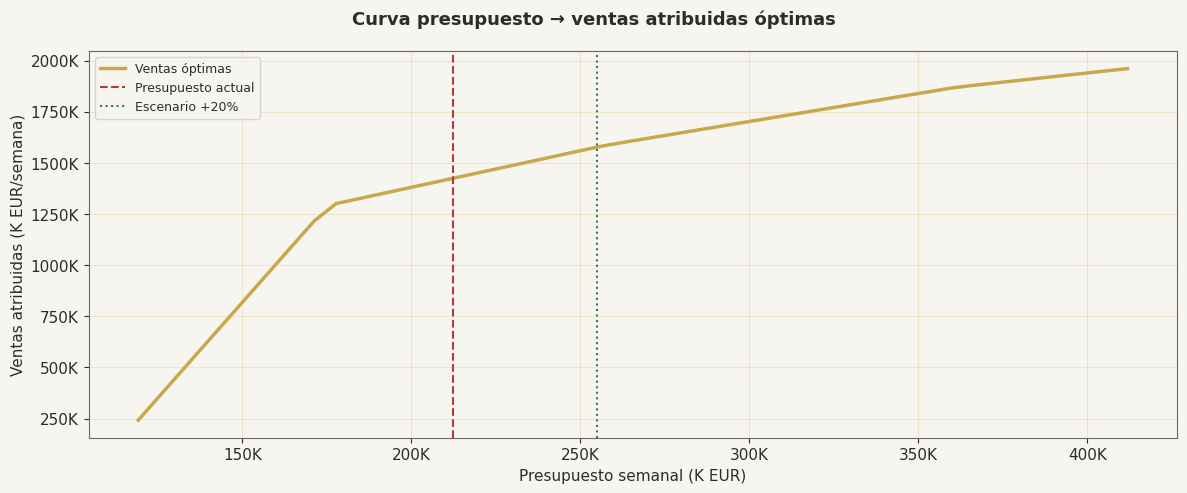

In [18]:
budgets  = np.linspace(inv_total_semanal * 0.5, inv_total_semanal * 2.0, 50)
ventas_c = []
for b in budgets:
    r, msg = optimizar_presupuesto(df_base, b)
    ventas_c.append(r['Ventas_optimas'].sum() if r is not None else np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Curva presupuesto → ventas atribuidas óptimas',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

ax.plot(budgets / 1e3, np.array(ventas_c) / 1e3,
        color=KM['gold'], lw=2.5, label='Ventas óptimas')
ax.axvline(inv_total_semanal / 1e3, color=KM['negative'],
           lw=1.5, ls='--', label='Presupuesto actual')
ax.axvline(inv_total_semanal * 1.2 / 1e3, color=KM['positive'],
           lw=1.5, ls=':', label='Escenario +20%')
ax.set_xlabel('Presupuesto semanal (K EUR)')
ax.set_ylabel('Ventas atribuidas (K EUR/semana)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
ax.legend(fontsize=9)

plt.tight_layout()
save_fig('08b_curva_respuesta')
plt.show()

## 8. Resumen de escenarios

  Guardado: img\08c_escenarios.png


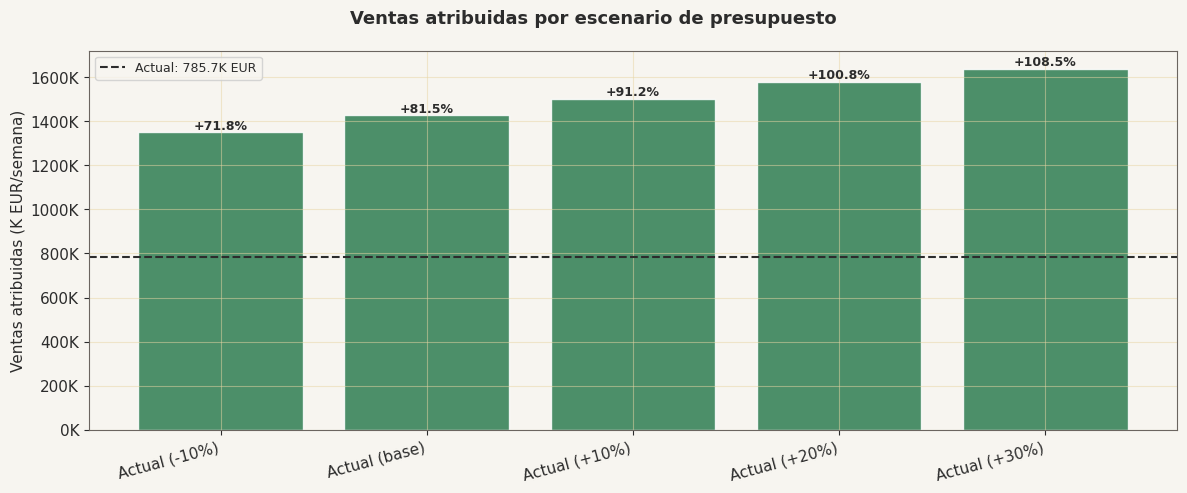

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Ventas atribuidas por escenario de presupuesto',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

nombres  = list(resultados_esc.keys())
ventas_e = [resultados_esc[n]['ventas'] for n in nombres]
uplifts  = [resultados_esc[n]['uplift'] for n in nombres]
colors_e = [KM['negative'] if u < 0 else (KM['neutral'] if u == 0 else KM['positive'])
            for u in uplifts]

bars = ax.bar(nombres, np.array(ventas_e)/1e3, color=colors_e, alpha=0.85, edgecolor='white')
ax.axhline(ventas_actual/1e3, color=KM['charcoal'], lw=1.5, ls='--',
           label=f'Actual: {ventas_actual/1e3:.1f}K EUR')

for bar, uplift, ventas in zip(bars, uplifts, ventas_e):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{uplift:+.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=KM['charcoal'])

ax.set_ylabel('Ventas atribuidas (K EUR/semana)')
ax.set_xticklabels(nombres, rotation=15, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
ax.legend(fontsize=9)

plt.tight_layout()
save_fig('08c_escenarios')
plt.show()

## 9. Exportación

In [20]:
# Exportar todas las distribuciones óptimas
rows = []
for nombre, esc in resultados_esc.items():
    df_e = esc['df'][['Canal','Inv_actual_sem','Inv_optima','Delta_pct','ROAS','Ventas_optimas']].copy()
    df_e['Escenario'] = nombre
    df_e['Budget_total'] = esc['budget']
    rows.append(df_e)

df_budget = pd.concat(rows, ignore_index=True)
df_budget.to_parquet(DATA_OUT / 'df_budget_optimizado.parquet', index=False)
print(f'df_budget_optimizado.parquet guardado: {df_budget.shape}')
print()

# Recomendacion ejecutiva
df_rec = resultados_esc['Actual (base)']['df'].sort_values('ROAS', ascending=False)
print('RECOMENDACION EJECUTIVA (redistribucion con mismo presupuesto):')
print()
aumentar = df_rec[df_rec['Delta_pct'] > 5]
reducir  = df_rec[df_rec['Delta_pct'] < -5]
if not aumentar.empty:
    print('  Aumentar inversion:')
    for _, r in aumentar.iterrows():
        print(f'    {r["Canal"]:15s}  {r["Delta_pct"]:+.0f}%  (ROAS={r["ROAS"]:.1f}x)')
if not reducir.empty:
    print('  Reducir inversion:')
    for _, r in reducir.iterrows():
        print(f'    {r["Canal"]:15s}  {r["Delta_pct"]:+.0f}%  (ROAS={r["ROAS"]:.1f}x)')

df_budget_optimizado.parquet guardado: (40, 8)

RECOMENDACION EJECUTIVA (redistribucion con mismo presupuesto):

  Aumentar inversion:
    Exterior         +150%  (ROAS=18.7x)
    Social Paid      +30%  (ROAS=3.6x)
  Reducir inversion:
    Paid Search      -70%  (ROAS=2.7x)
    Radio Local      -70%  (ROAS=1.8x)


## 10. Resumen de la Fase 8

| Escenario | Uplift ventas atribuidas |
|---|---|
| -10% presupuesto | Ver output |
| Base redistribuido | Ver output |
| +10% | Ver output |
| +20% | Ver output |
| +30% | Ver output |

**Metodología:** Programación lineal (scipy HiGHS) con floor=30% / ceiling=250% por canal.  
**Limitación:** Modelo lineal — no captura saturación. En la realidad, duplicar presupuesto de Exterior no duplicaría ventas.

**Siguiente fase:** `09_dashboard_streamlit.py` — Dashboard interactivo con toda la información del pipeline.